# PerturbRadius quickstart

This is the single, self-contained tutorial for the minimal PerturbRadius package. It creates a synthetic spatial CRISPR screen with a known non-cell-autonomous decay, calls guide-labelled source components, constructs boundary-distance rings, estimates an NTC-adjusted response, and applies the evidence gate.

The example is deliberately small and CPU-friendly. Coordinates are in micrometres. The simulated perturbation has a generating length scale of **60 µm**; fitted values are diagnostic estimates after far-field centring and therefore need not equal the generating value exactly.

## 1. Imports and plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display
import perturbradius as pr

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLORS = {"GeneA": "#D55E00", "NTC": "#0072B2", "target": "#777777"}
print("PerturbRadius", pr.__version__)

PerturbRadius 0.1.0


## 2. Generate a synthetic spatial screen

Each of three sections contains one GeneA source component and one NTC source component. Independent guide labels are nested across sections, and each section represents a different mouse. The response is generated around the GeneA source boundary with additive noise and a section-specific offset.

In [2]:
rng = np.random.default_rng(7)
x_axis = np.arange(0.0, 801.0, 10.0)
y_axis = np.arange(0.0, 601.0, 10.0)
xx, yy = np.meshgrid(x_axis, y_axis)
xy = np.column_stack([xx.ravel(), yy.ravel()])

gene_center = np.array([200.0, 300.0])
ntc_center = np.array([600.0, 300.0])
source_radius_um = 32.0
true_amplitude = 0.90
true_lambda_um = 60.0
frames = []

for number, section in enumerate(("S1", "S2", "S3"), start=1):
    d_gene = np.linalg.norm(xy - gene_center, axis=1)
    d_ntc = np.linalg.norm(xy - ntc_center, axis=1)
    gene_source = d_gene <= source_radius_um
    ntc_source = d_ntc <= source_radius_um
    boundary_distance = np.maximum(d_gene - source_radius_um, 0.0)

    section_offset = (number - 2) * 0.025
    response = true_amplitude * np.exp(-boundary_distance / true_lambda_um)
    response += section_offset + rng.normal(0.0, 0.018, len(response))

    target = np.full(len(response), "unassigned", dtype=object)
    guide = np.full(len(response), "", dtype=object)
    target[gene_source] = "GeneA"
    guide[gene_source] = f"sgGeneA_{1 + (number - 1) % 2}"
    target[ntc_source] = "NTC"
    guide[ntc_source] = f"NTC_{1 + (number - 1) % 2}"

    frames.append(pd.DataFrame({
        "section": section,
        "mouse": f"M{number}",
        "x_um": xy[:, 0],
        "y_um": xy[:, 1],
        "target_gene": target,
        "guide": guide,
        "is_source": gene_source | ntc_source,
        "is_ntc": ntc_source,
        "response": response,
    }))

data = pd.concat(frames, ignore_index=True)
pd.DataFrame({
    "rows": [len(data)],
    "sections": [data["section"].nunique()],
    "mice": [data["mouse"].nunique()],
    "source bins": [int(data["is_source"].sum())],
    "GeneA guides": [data.loc[data["target_gene"].eq("GeneA"), "guide"].nunique()],
    "NTC guides": [data.loc[data["is_ntc"], "guide"].nunique()],
})

,rows,sections,mice,source bins,GeneA guides,NTC guides
0,14823,3,3,222,2,2


### Spatial input overview

The left panel shows the simulated response in one section. The right panel makes source identity explicit. GeneA and NTC source regions are spatially separated.

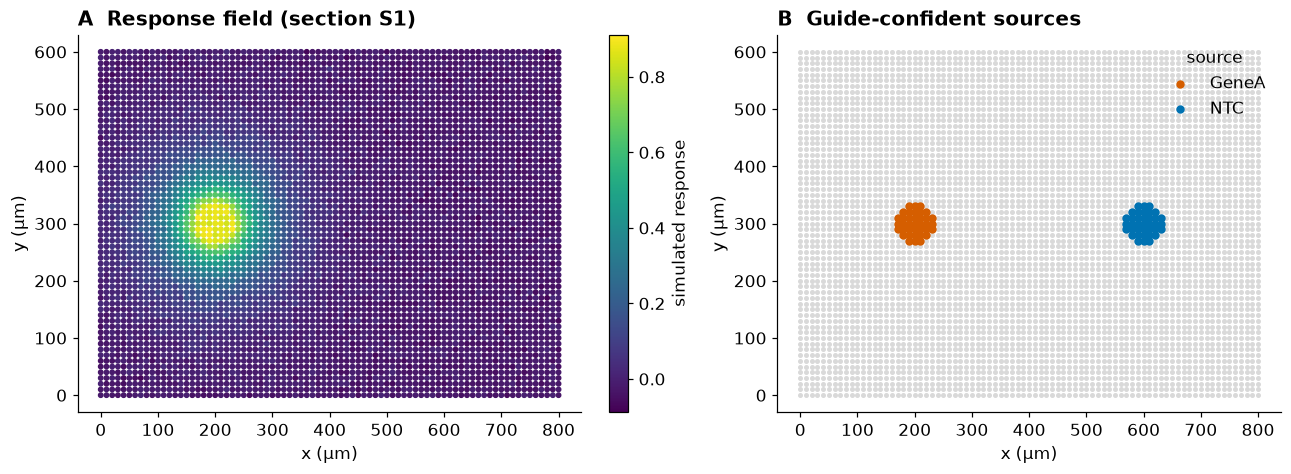

In [3]:
section = data.loc[data["section"].eq("S1")].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

response_map = axes[0].scatter(
    section["x_um"], section["y_um"], c=section["response"],
    s=8, cmap="viridis", rasterized=True,
)
fig.colorbar(response_map, ax=axes[0], label="simulated response")
axes[0].set_title("A  Response field (section S1)", loc="left", fontweight="bold")

axes[1].scatter(section["x_um"], section["y_um"], s=5, color="#D9D9D9", rasterized=True)
for label, color in (("GeneA", COLORS["GeneA"]), ("NTC", COLORS["NTC"])):
    source = section.loc[section["is_source"] & section["target_gene"].eq(label)]
    axes[1].scatter(source["x_um"], source["y_um"], s=20, color=color, label=label)
axes[1].legend(frameon=False, title="source")
axes[1].set_title("B  Guide-confident sources", loc="left", fontweight="bold")

for ax in axes:
    ax.set(xlabel="x (µm)", ylabel="y (µm)", aspect="equal")
plt.show()

## 3. Run the minimal PerturbRadius workflow

`analyze_radius` validates the table, calls DBSCAN source components separately by section/target/guide, assigns non-source targets to the nearest component boundary, constructs rings, computes a far-centred GeneA-minus-NTC curve, fits a signed exponential, and applies the reporting gate.

In [4]:
ring_edges = (0, 20, 40, 80, 120, 180, 240)
result = pr.analyze_radius(
    data,
    perturbation="GeneA",
    response_col="response",
    ring_edges=ring_edges,
    eps_um=15,
    min_samples=4,
    min_source_bins=15,
    bin_size_um=10,
    replicate_col="mouse",
)

component_summary = result.components.summary.copy()
display(component_summary)

,component_id,section,target_gene,guide,is_ntc,n_source_bins,centroid_x_um,centroid_y_um
0,C0001,S1,GeneA,sgGeneA_1,False,37,200.0,300.0
1,C0002,S1,NTC,NTC_1,True,37,600.0,300.0
2,C0003,S2,GeneA,sgGeneA_2,False,37,200.0,300.0
3,C0004,S2,NTC,NTC_2,True,37,600.0,300.0
4,C0005,S3,GeneA,sgGeneA_1,False,37,200.0,300.0
5,C0006,S3,NTC,NTC_1,True,37,600.0,300.0


The expected result is six source components: one GeneA and one NTC component in each of three sections. Component IDs are algorithmic spatial units; they should not automatically be interpreted as independent biological clones.

### Boundary-distance ring QC

Targets are assigned to their nearest source component and coloured by distance ring. Source bins are drawn on top. Subsampled black crosses mark targets that fall within the analysed field of more than one source and are excluded from the default effect estimate.

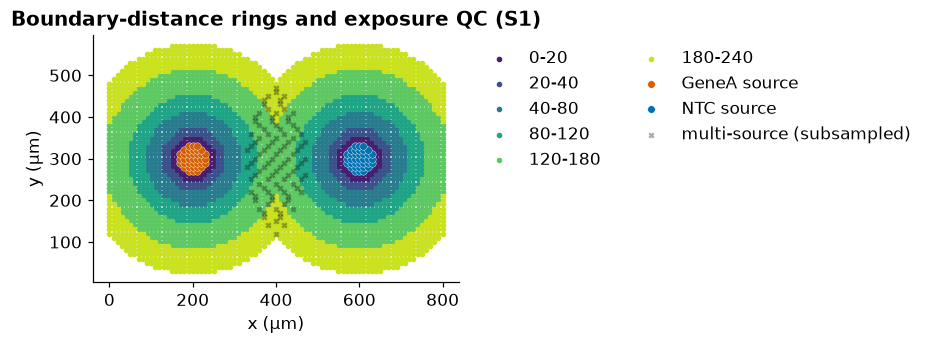

In [5]:
rings_s1 = result.ring_table.loc[result.ring_table["section"].eq("S1")].copy()
sources_s1 = data.loc[data["section"].eq("S1") & data["is_source"]].copy()
ring_labels = (
    rings_s1[["ring_index", "ring"]]
    .drop_duplicates().sort_values("ring_index")["ring"].tolist()
)
ring_colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(ring_labels)))

fig, ax = plt.subplots(figsize=(8.2, 5.2), constrained_layout=True)
for ring_index, (ring_label, color) in enumerate(zip(ring_labels, ring_colors)):
    rows = rings_s1.loc[rings_s1["ring_index"].eq(ring_index)]
    ax.scatter(rows["x_um"], rows["y_um"], s=7, color=color, label=ring_label, rasterized=True)
for label, color in (("GeneA", COLORS["GeneA"]), ("NTC", COLORS["NTC"])):
    rows = sources_s1.loc[sources_s1["target_gene"].eq(label)]
    ax.scatter(rows["x_um"], rows["y_um"], s=24, color=color, edgecolor="white", linewidth=0.25, label=f"{label} source")
overlap = rings_s1.loc[rings_s1["multi_source_exposure"]].iloc[::4]
ax.scatter(overlap["x_um"], overlap["y_um"], s=9, marker="x", alpha=0.35, color="#111111", label="multi-source (subsampled)")
ax.set(xlabel="x (µm)", ylabel="y (µm)", aspect="equal")
ax.set_title("Boundary-distance rings and exposure QC (S1)", fontweight="bold")
ax.legend(frameon=False, ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## 4. Inspect the NTC-adjusted distance response

For each component and ring, PerturbRadius first subtracts that component's far-field value. It then subtracts the mean NTC profile from the perturbation profile. Replication is counted at component level, not by treating every spatial bin as independent.

In [6]:
effect_columns = [
    "ring", "distance_midpoint_um", "perturbation_effect", "ntc_effect",
    "effect", "effect_se", "n_perturbation_components", "n_ntc_components",
]
display(result.effect_table[effect_columns].round(4))

,ring,distance_midpoint_um,perturbation_effect,ntc_effect,effect,effect_se,n_perturbation_components,n_ntc_components
0,0-20,10.0,0.6937,0.0038,0.6899,0.0022,3,3
1,20-40,30.0,0.4813,0.0007,0.4806,0.0011,3,3
2,40-80,60.0,0.2797,0.0007,0.2790,0.0021,3,3
3,80-120,100.0,0.1368,0.0014,0.1354,0.0013,3,3
4,120-180,150.0,0.0457,0.0013,0.0444,0.0007,3,3
5,180-240,210.0,0.0000,0.0000,0.0000,0.0000,3,3


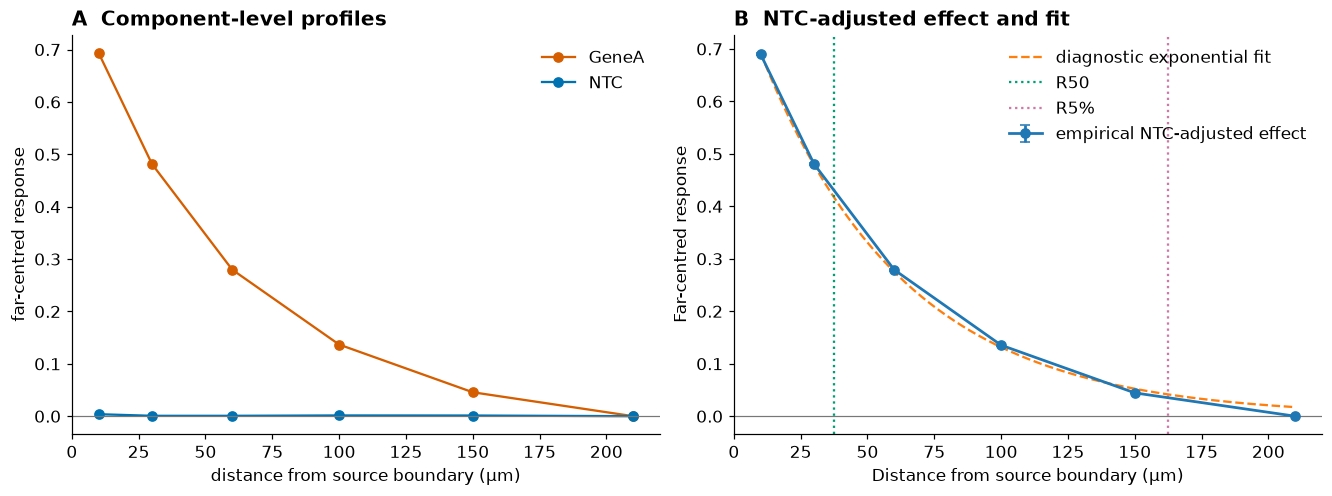

In [7]:
table = result.effect_table
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)

axes[0].plot(table["distance_midpoint_um"], table["perturbation_effect"], "o-", color=COLORS["GeneA"], label="GeneA")
axes[0].plot(table["distance_midpoint_um"], table["ntc_effect"], "o-", color=COLORS["NTC"], label="NTC")
axes[0].axhline(0, color="#777777", linewidth=0.8)
axes[0].set(xlabel="distance from source boundary (µm)", ylabel="far-centred response")
axes[0].set_title("A  Component-level profiles", loc="left", fontweight="bold")
axes[0].legend(frameon=False)

pr.plot_distance_response(result, ax=axes[1])
axes[1].set_title("", loc="center")
axes[1].set_title("B  NTC-adjusted effect and fit", loc="left", fontweight="bold")
axes[1].axvline(result.model_fit.r50_um, color="#009E73", linestyle=":", linewidth=1.5, label="R50")
axes[1].axvline(result.model_fit.r5_um, color="#CC79A7", linestyle=":", linewidth=1.5, label="R5%")
axes[1].legend(frameon=False)
plt.show()

## 5. Summarise the fitted scale and evidence decision

`length_scale_um` is the exponential λ. `R50 = λ ln(2)` is the distance at which the fitted effect falls to 50% of its boundary amplitude; `R5% = λ ln(20)` is the approximate 5% distance. These numbers are only reportable when `radius_decision.reportable` is true.

In [8]:
fit = result.model_fit
fit_summary = pd.DataFrame({
    "quantity": ["generating λ", "fitted amplitude", "fitted λ", "R50", "R5%", "model R²", "monotonic", "radius reportable"],
    "value": [
        f"{true_lambda_um:.1f} µm",
        f"{fit.amplitude:.3f}",
        f"{fit.length_scale_um:.1f} µm",
        f"{fit.r50_um:.1f} µm",
        f"{fit.r5_um:.1f} µm",
        f"{fit.r_squared:.3f}",
        str(fit.monotonic),
        str(result.radius_decision.reportable),
    ],
})
display(fit_summary)
print("Evidence-gate reasons:", result.radius_decision.reasons or "none")

,quantity,value
0,generating λ,60.0 µm
1,fitted amplitude,0.833
2,fitted λ,54.2 µm
3,R50,37.6 µm
4,R5%,162.3 µm
5,model R²,0.999
6,monotonic,True
7,radius reportable,True


Evidence-gate reasons: none


### Ring-width sensitivity

A stable conclusion should not depend on one arbitrary ring definition. Here we rerun the full workflow with three reasonable ring schemes and compare λ, R50 and model fit. This is a compact diagnostic, not a substitute for clone-level bootstrap or held-out biological replication.

,ring scheme,number of rings,λ (µm),R50 (µm),R²,reportable
0,fine,7,53.927,37.379,0.999,True
1,default,6,54.176,37.552,0.999,True
2,coarse,5,54.544,37.807,0.998,True


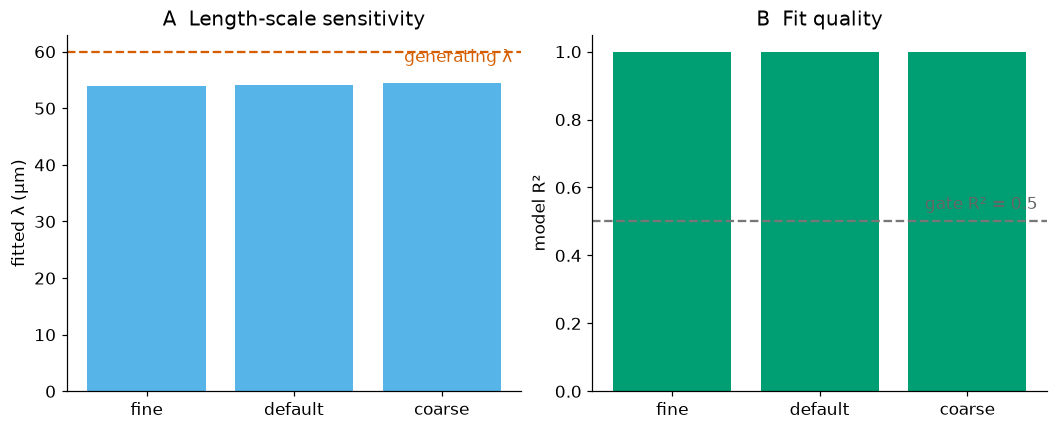

In [9]:
ring_schemes = {
    "fine": (0, 20, 40, 60, 90, 120, 180, 240),
    "default": (0, 20, 40, 80, 120, 180, 240),
    "coarse": (0, 40, 80, 120, 180, 240),
}
sensitivity_rows = []
for name, edges in ring_schemes.items():
    run = pr.analyze_radius(
        data, perturbation="GeneA", response_col="response", ring_edges=edges,
        eps_um=15, min_samples=4, min_source_bins=15, bin_size_um=10,
        replicate_col="mouse",
    )
    sensitivity_rows.append({
        "ring scheme": name,
        "number of rings": len(edges) - 1,
        "λ (µm)": run.model_fit.length_scale_um,
        "R50 (µm)": run.model_fit.r50_um,
        "R²": run.model_fit.r_squared,
        "reportable": run.radius_decision.reportable,
    })
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.round(3))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), constrained_layout=True)
axes[0].bar(sensitivity["ring scheme"], sensitivity["λ (µm)"], color="#56B4E9")
axes[0].axhline(true_lambda_um, color="#D55E00", linestyle="--", label="generating λ")
axes[0].set(ylabel="fitted λ (µm)", title="A  Length-scale sensitivity")
axes[0].text(0.98, 0.96, "generating λ", transform=axes[0].transAxes, ha="right", va="top", color="#D55E00")
axes[1].bar(sensitivity["ring scheme"], sensitivity["R²"], color="#009E73")
axes[1].axhline(0.5, color="#777777", linestyle="--", label="evidence-gate threshold")
axes[1].set(ylim=(0, 1.05), ylabel="model R²", title="B  Fit quality")
axes[1].text(0.98, 0.50, "gate R² = 0.5", transform=axes[1].transAxes, ha="right", va="bottom", color="#666666")
plt.show()

## 6. Demonstrate the evidence gate

The same numerical fit becomes descriptive-only when no biological-replicate column is supplied. This separation prevents a visually smooth curve from being over-interpreted as a formally supported propagation radius.

In [10]:
descriptive_only = pr.analyze_radius(
    data,
    perturbation="GeneA",
    response_col="response",
    ring_edges=ring_edges,
    eps_um=15,
    min_samples=4,
    min_source_bins=15,
    bin_size_um=10,
    replicate_col=None,
)
pd.DataFrame({
    "analysis": ["with mouse replication", "replicate information omitted"],
    "same fitted λ (µm)": [result.model_fit.length_scale_um, descriptive_only.model_fit.length_scale_um],
    "radius reportable": [result.radius_decision.reportable, descriptive_only.radius_decision.reportable],
    "reason": ["none", "; ".join(descriptive_only.radius_decision.reasons)],
}).round(3)

,analysis,same fitted λ (µm),radius reportable,reason
0,with mouse replication,54.176,True,none
1,replicate information omitted,54.176,False,biological replicate column unavailable


## 7. Adapting this tutorial to real data

Replace the synthetic `data` table with one row per cell or spatial bin and preserve the required columns documented in the README. Before interpreting a radius:

1. verify that `x_um` and `y_um` are genuinely calibrated in micrometres;
2. define `is_source` from guide-confidence evidence rather than treating guide non-detection as an unperturbed cell;
3. keep source perturbations restricted to the biologically relevant compartment (for example malignant cells);
4. audit component boundaries, tissue edges and multi-source exposure;
5. use mouse/section/clone as replication units and confirm multiple guides per gene;
6. treat the exponential result as descriptive when the response is non-monotonic or the evidence gate fails.

The minimal package intentionally stops short of cell-level causal inference, complex matching, hierarchical modelling and GNNs. Those should be added only after the clone-centric baseline is stable.